In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import matplotlib.cm as cm
import os

In [80]:
def concat_dfs(heuristic, types):
    dfs = []
    
    for t in types:
        file_path = f"./output/{heuristic}/{t}/output.csv"
        try:
            df = pd.read_csv(file_path)
            df["type"] = t
            df["algorithm"] = heuristic
            dfs.append(df)
        except FileNotFoundError:
            print(f"File not found: {file_path}")
            df = None 
    
    final_df = pd.concat(dfs, ignore_index=True)
    return final_df

In [170]:
def compare_obj_value_time_for_diff_algorithm_types_subplots(df_all, name, filter_nreq, legend_col, display_by_column=None, display_by_column_value=None):

    df_all = df_all[df_all['nreq'] == filter_nreq]
    append_titel=""
    if display_by_column and display_by_column_value:
        df_all = df_all[df_all[display_by_column] == display_by_column_value]
        append_titel = f"{display_by_column}_{display_by_column_value}"
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

    metrics = [
        ("avg_obj_func", "Average Objective Function"),
        ("avg_time", "Average Time")
    ]

    for ax, (value, label_part) in zip(axes, metrics):
        for t in df_all[legend_col].unique():
            subset = df_all[df_all[legend_col] == t]
            ax.plot(
                subset["number"],
                subset[value],
                marker=".",
                linestyle="-",
                label=t
            )
        
        ax.set_xlabel("Instance")
        ax.set_ylabel(label_part)
        ax.set_title(f"{name} {append_titel}: {label_part} by Type")
        ax.legend(title=legend_col.title())

    plt.tight_layout()
    plt.show()

In [171]:
def compare_obj_value_time_for_diff_algorithm_types_boxplots(df_all, name, legend_col, display_by_column=None, display_by_column_value=None):
    """
    Create boxplots of avg_obj_func and avg_time for different 'nreq' and algorithm types.
    """
    df_plot = df_all.copy()
    
    append_title = ""
    if display_by_column and display_by_column_value:
        df_plot = df_plot[df_plot[display_by_column] == display_by_column_value]
        append_title = f"{display_by_column}_{display_by_column_value}"

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Metrics to plot
    metrics = [
        ("avg_obj_func", "Average Objective Function"),
        ("avg_time", "Average Time")
    ]
    
    for ax, (metric, ylabel) in zip(axes, metrics):
        sns.boxplot(
            x="nreq",
            y=metric,
            hue=legend_col,
            data=df_plot,
            ax=ax
        )
        ax.set_xlabel("Number of Customers")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{name} {append_title}: {ylabel} by Number of Customers and Type")
        ax.legend(title=legend_col.title())

    plt.tight_layout()
    plt.show()

## Construction Heuristic

In [172]:
df_construction = concat_dfs("c", ["pure", "with_reordering"])
display(df_construction)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm
0,1,50,2,48,60.86,0.279413,3668.41,46.0,pure,c
1,2,50,2,45,16.88,0.211428,3108.92,43.0,pure,c
2,3,50,2,46,47.73,0.254875,3127.70,44.0,pure,c
3,4,50,2,47,66.33,0.258550,3637.60,45.0,pure,c
4,5,50,2,45,60.86,0.244776,3289.06,43.0,pure,c
...,...,...,...,...,...,...,...,...,...,...
115,26,100,2,88,14.38,28.484738,4178.08,88.0,with_reordering,c
116,27,100,2,89,56.48,35.878927,4292.38,88.0,with_reordering,c
117,28,100,2,85,24.06,29.186069,4045.29,88.0,with_reordering,c
118,29,100,2,86,45.55,26.529978,3795.43,84.0,with_reordering,c


### Compare Average Objective Funciton, Run Time for 100 customers

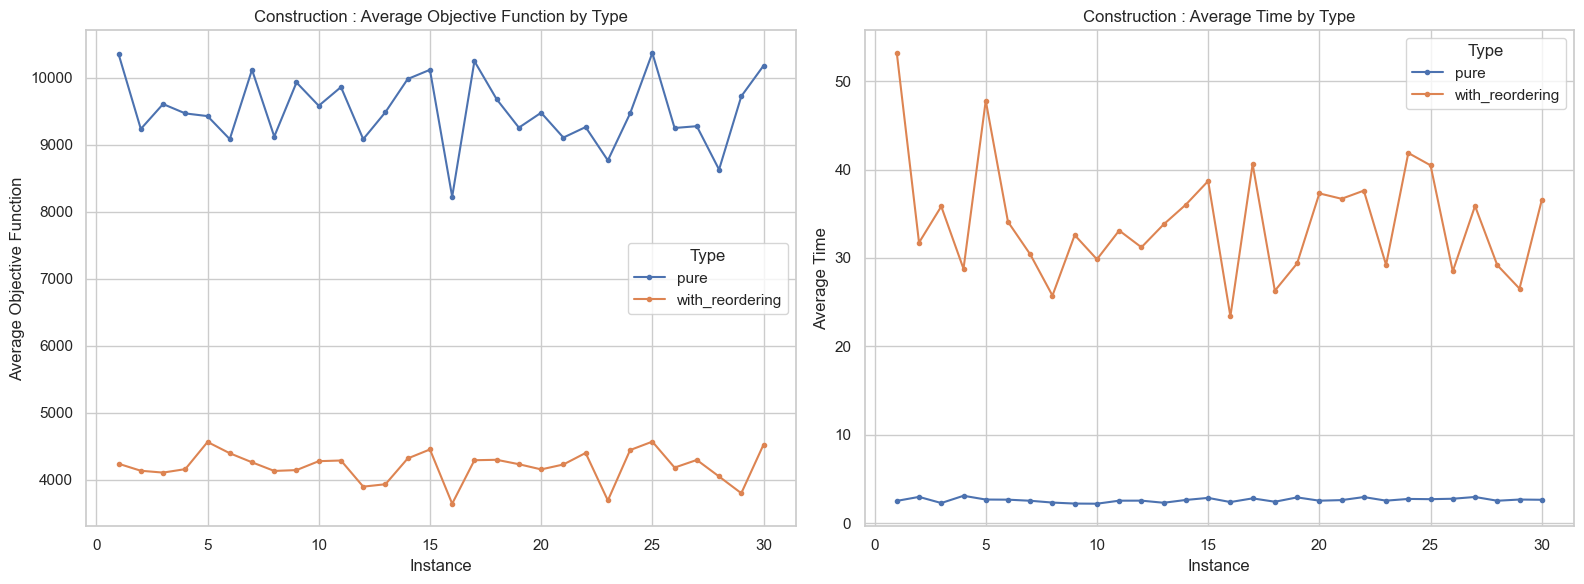

In [173]:
compare_obj_value_time_for_diff_algorithm_types_subplots(df_construction, "Construction", 100, "type")

### Compare Average Objective Funciton, Run Time for different number of customers

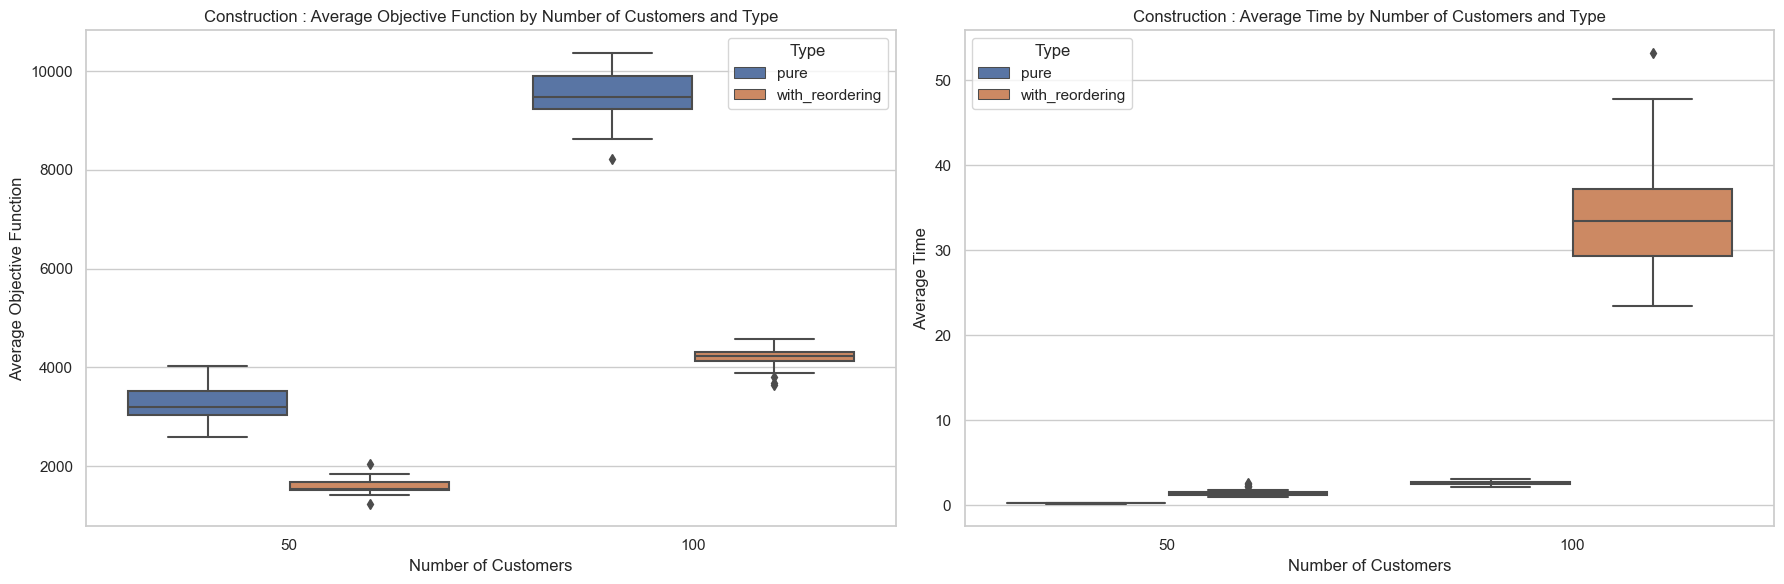

In [154]:
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_construction, "Construction", "type")

## Randomized Construction heuristic

In [156]:
df_construction_random = concat_dfs("rc", ["pure", "with_reordering"])
display(df_construction_random)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm
0,1,100,2,98,42.27,2.190890,10507.87,96.0,pure,rc
1,2,100,2,88,44.45,1.620554,9554.83,86.0,pure,rc
2,3,100,2,91,52.11,1.510261,9746.66,89.0,pure,rc
3,4,100,2,89,24.06,1.546330,9703.37,87.0,pure,rc
4,5,100,2,94,79.73,1.605934,9784.30,92.0,pure,rc
...,...,...,...,...,...,...,...,...,...,...
115,26,50,2,47,27.81,2.332592,1887.14,47.0,with_reordering,rc
116,27,50,2,43,29.69,1.395176,1580.46,43.0,with_reordering,rc
117,28,50,2,41,37.19,1.563045,1508.64,40.0,with_reordering,rc
118,29,50,2,45,80.90,2.009985,1699.22,43.0,with_reordering,rc


### Compare Average Objective Funciton, Run Time for 100 customers

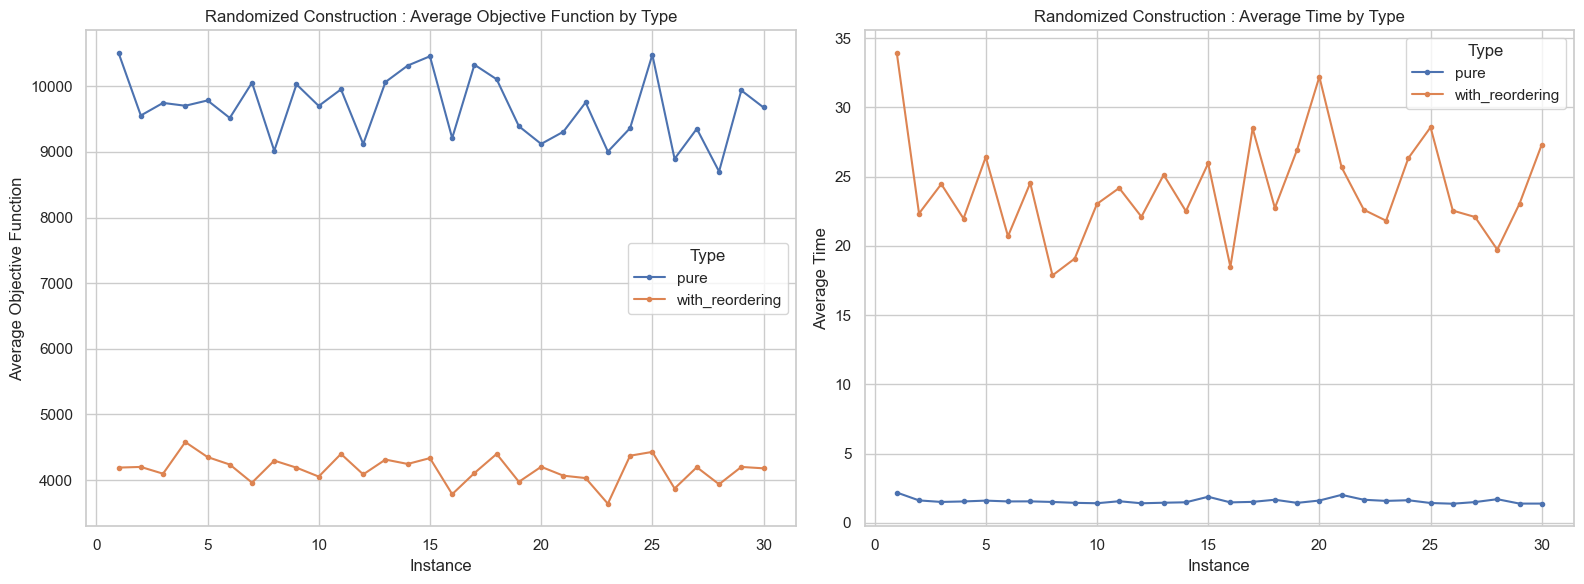

In [174]:
compare_obj_value_time_for_diff_algorithm_types_subplots(df_construction_random, "Randomized Construction", 100, "type")

### Compare Average Objective Funciton, Run Time for 100 customers

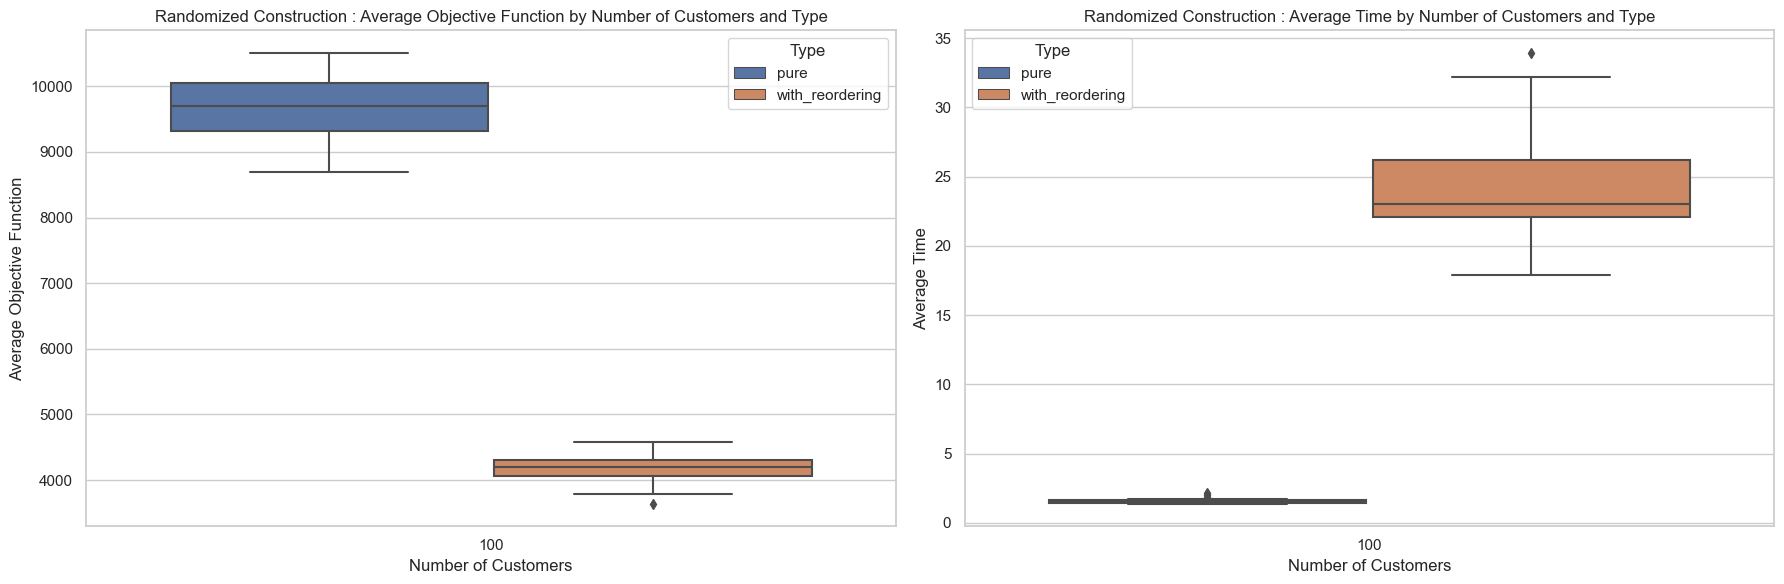

In [158]:
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_construction_random[df_construction_random["nreq"] == 100], "Randomized Construction", "type")

### Compare Average Objective Funciton: degree of randomization (with reordering)

In [161]:
df_construction_random_3 = concat_dfs("rc/alpha_0.3", ["pure", "with_reordering"])
df_construction_random_3 = df_construction_random_3[df_construction_random_3["type"] == "with_reordering"]
df_construction_random_3["degree of randomization"] = "0.3"
df_construction_random_5 = concat_dfs("rc/alpha_0.5", ["pure", "with_reordering"])
df_construction_random_5 = df_construction_random_5[df_construction_random_5["type"] == "with_reordering"]
df_construction_random_5["degree of randomization"] = "0.5"
df_combined = pd.concat([df_construction_random_3, df_construction_random_5], ignore_index=True)
display(df_combined)

File not found: ./output/rc/alpha_0.5/pure/output.csv


,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm,degree of randomization
0,1,100,2,98,42.27,33.926269,4190.74,96.0,with_reordering,rc/alpha_0.3,0.3
1,2,100,2,88,44.45,22.334355,4200.60,86.0,with_reordering,rc/alpha_0.3,0.3
2,3,100,2,91,52.11,24.458363,4097.55,89.0,with_reordering,rc/alpha_0.3,0.3
3,4,100,2,89,24.06,21.968577,4579.84,87.0,with_reordering,rc/alpha_0.3,0.3
4,5,100,2,94,79.73,26.409159,4351.06,92.0,with_reordering,rc/alpha_0.3,0.3
...,...,...,...,...,...,...,...,...,...,...,...
115,26,50,2,47,27.81,1.963566,1893.80,45.0,with_reordering,rc/alpha_0.5,0.5
116,27,50,2,43,29.69,1.464725,1730.69,41.0,with_reordering,rc/alpha_0.5,0.5
117,28,50,2,41,37.19,1.679896,1498.62,39.0,with_reordering,rc/alpha_0.5,0.5
118,29,50,2,45,80.90,1.551233,1643.70,43.0,with_reordering,rc/alpha_0.5,0.5


In [162]:
print(df_combined["degree of randomization"].unique())

['0.3' '0.5']


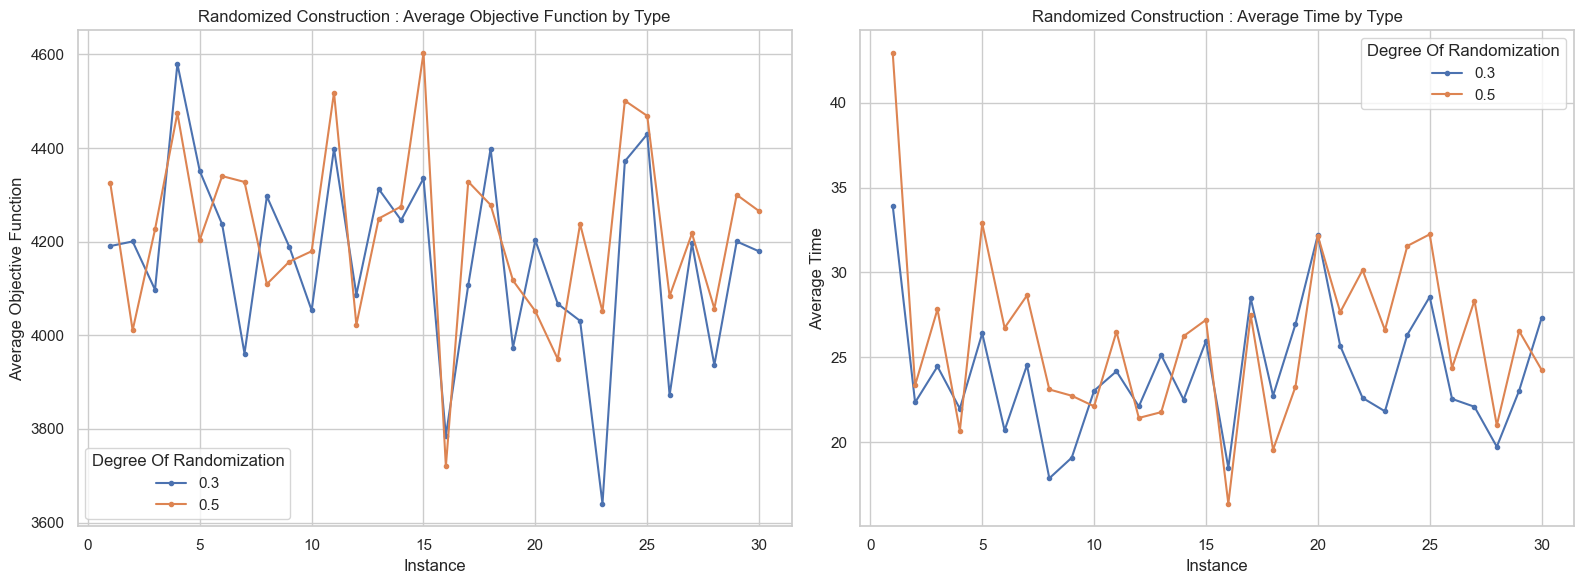

In [175]:
compare_obj_value_time_for_diff_algorithm_types_subplots(df_combined, "Randomized Construction", 100, "degree of randomization")

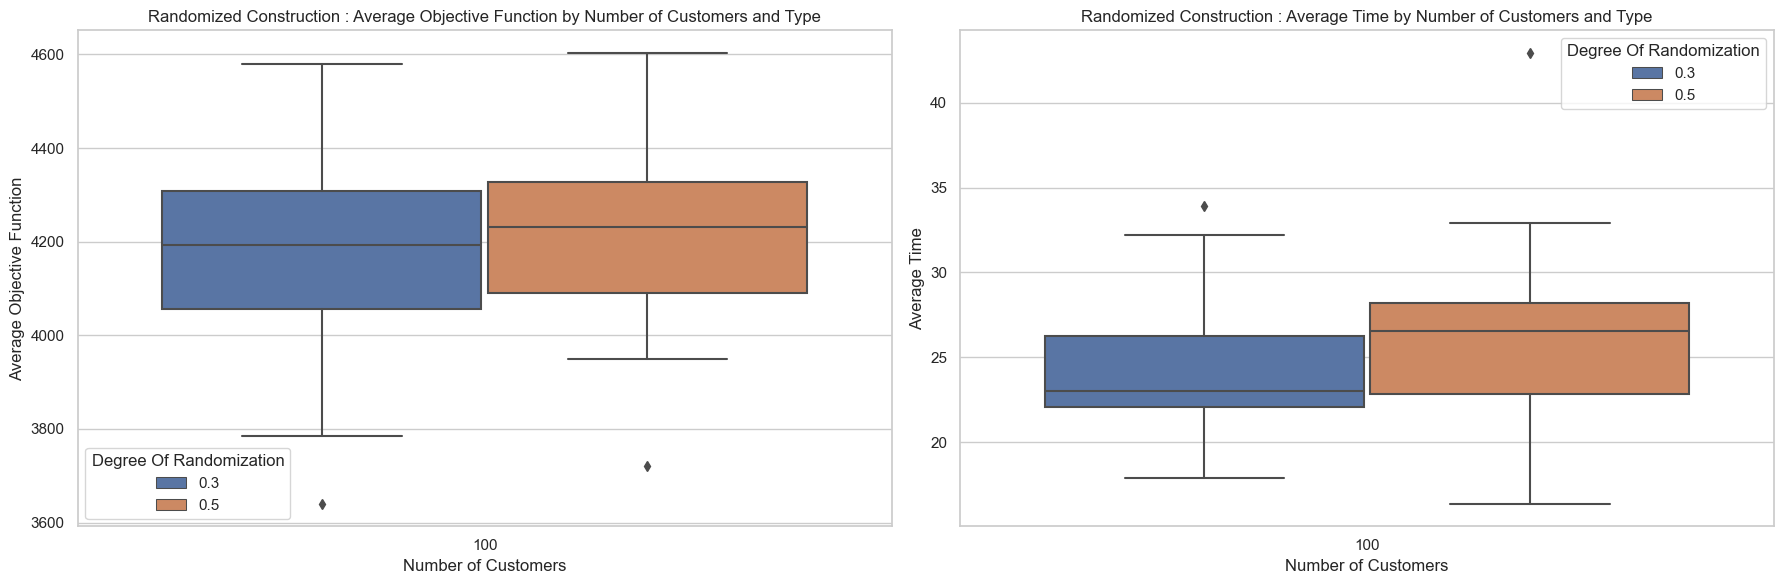

In [163]:
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_combined[df_combined["nreq"] == 100], "Randomized Construction", "degree of randomization")

## Local Search

In [192]:
list_nh = ['exchange', 'pickup_relocate', 'dropoff_relocate', 'remove_and_append', 'move']
list_str = ['best', 'first']

In [193]:
df_ls = concat_dfs("ls", [f"{nh}_{s}" for nh in list_nh for s in list_str])
df_ls[["neighborhood structures", "strategy"]] = df_ls["type"].str.rsplit("_", n=1, expand=True)
display(df_ls)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm,neighborhood structures,strategy
0,1,50,2,48,60.86,0.335403,1671.13,2.0,exchange_best,ls,exchange,best
1,2,50,2,45,16.88,0.453967,1362.43,3.0,exchange_best,ls,exchange,best
2,3,50,2,46,47.73,0.702261,1478.73,4.0,exchange_best,ls,exchange,best
3,4,50,2,47,66.33,0.351212,1704.37,2.0,exchange_best,ls,exchange,best
4,5,50,2,45,60.86,0.754946,1446.62,6.0,exchange_best,ls,exchange,best
...,...,...,...,...,...,...,...,...,...,...,...,...
295,26,50,2,47,27.81,64.619973,1824.90,47.0,move_first,ls,move,first
296,27,50,2,43,29.69,5.245329,1473.85,8.0,move_first,ls,move,first
297,28,50,2,41,37.19,54.419312,1241.60,41.0,move_first,ls,move,first
298,29,50,2,45,80.90,7.384458,1490.23,13.0,move_first,ls,move,first


### Compare Average Objective Funciton, Run Time for 50 customers: Different Neighborhood Structures

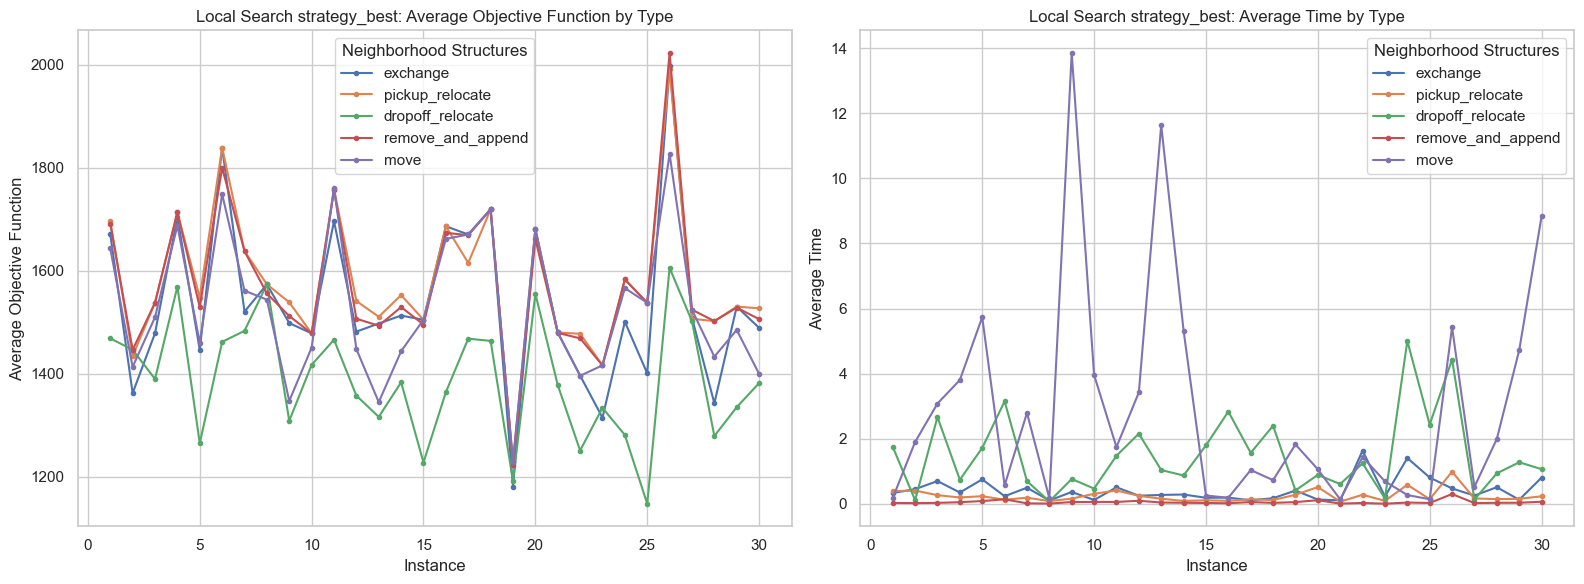

In [176]:
compare_obj_value_time_for_diff_algorithm_types_subplots(df_ls, "Local Search", 50, "neighborhood structures", 'strategy', "best")

### Compare Average Objective Funciton, Run Time for 50 customers: Different Neighborhood Structures

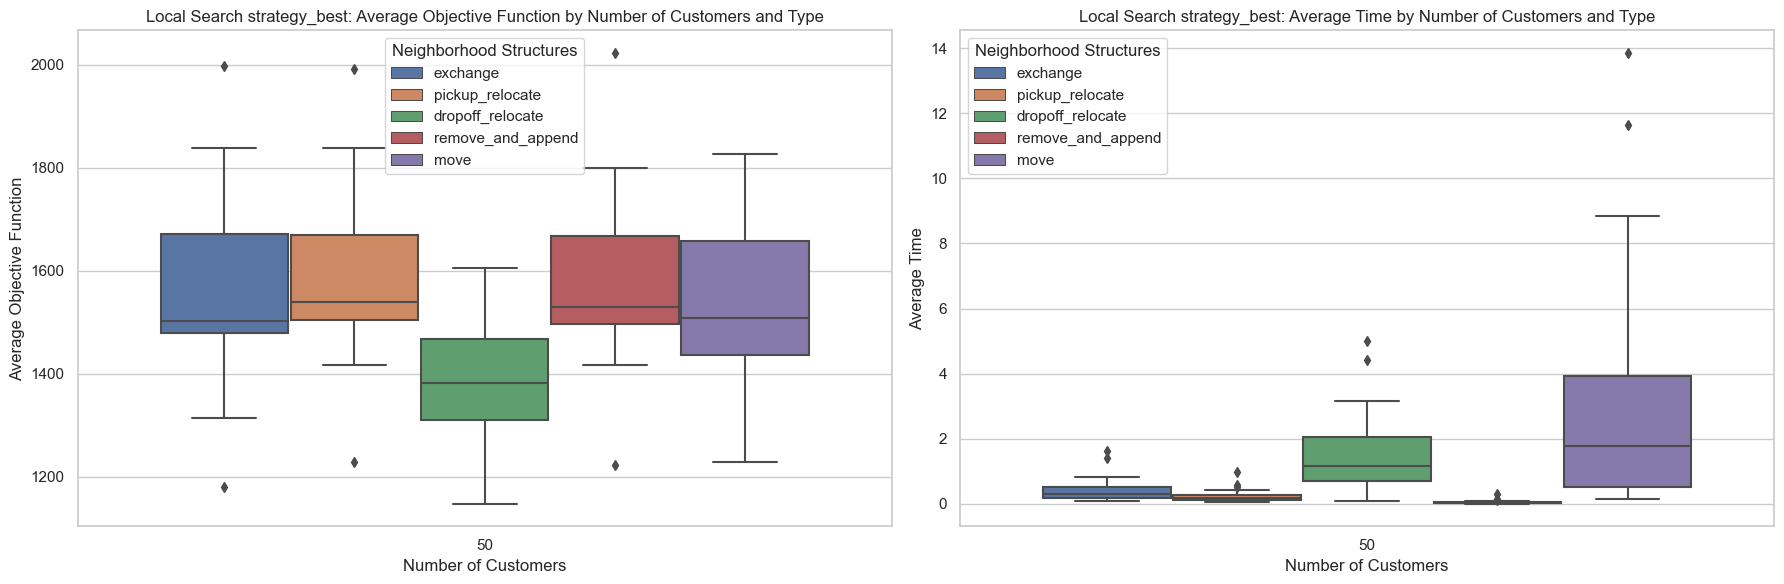

In [169]:
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_ls[df_ls["nreq"] == 50], "Local Search", "neighborhood structures", 'strategy', "best")

### Compare Average Objective Funciton, Run Time for 50 customers: Different Strategies

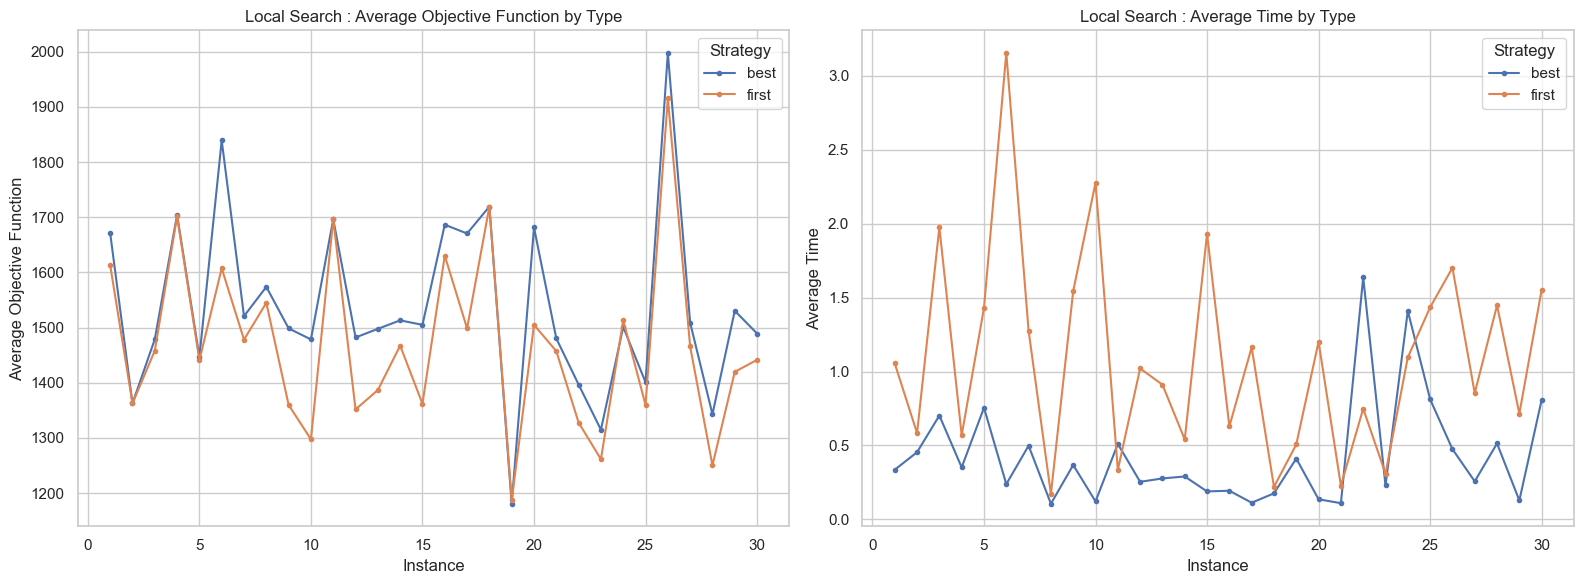

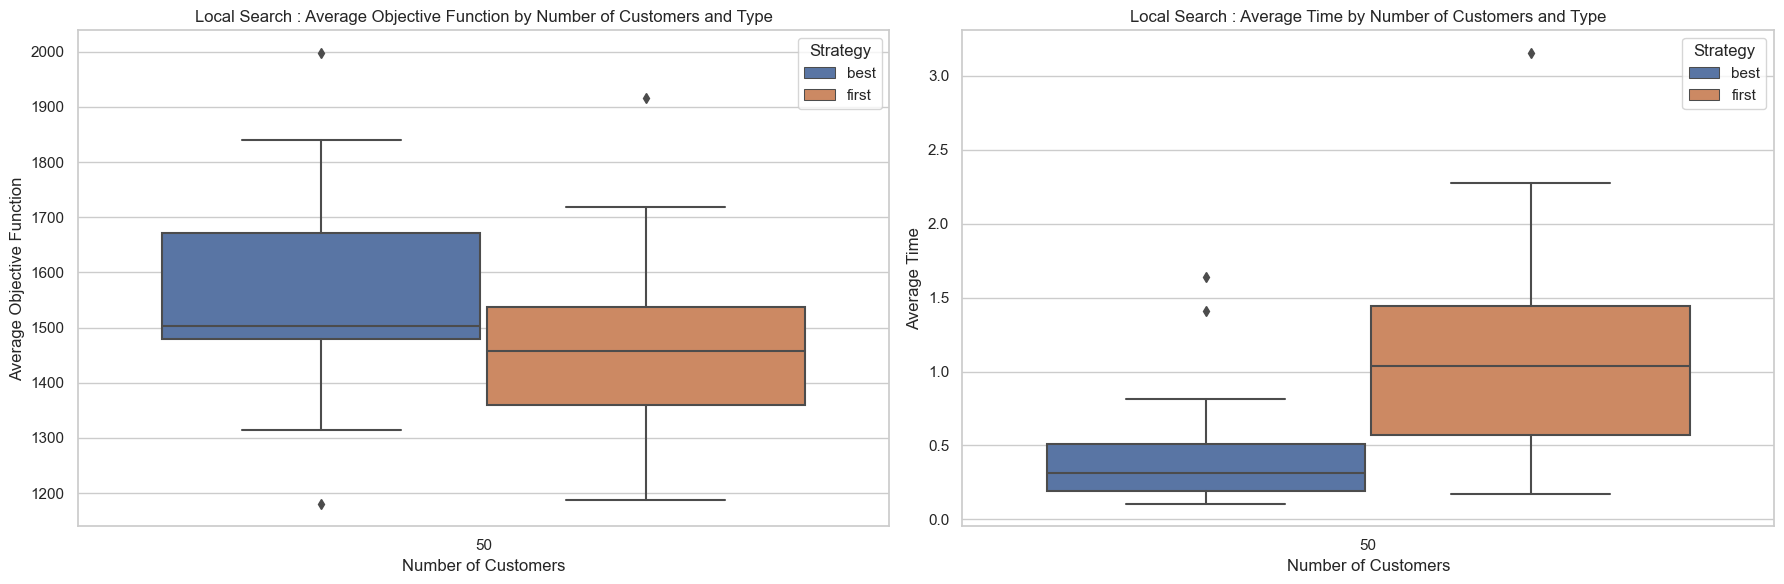

In [188]:
df_ls_str = df_ls[df_ls["neighborhood structures"] == "exchange"].copy() 
compare_obj_value_time_for_diff_algorithm_types_subplots(df_ls_str, "Local Search", 50, "strategy")
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_ls_str[df_ls_str["nreq"] == 50], "Local Search", "strategy")

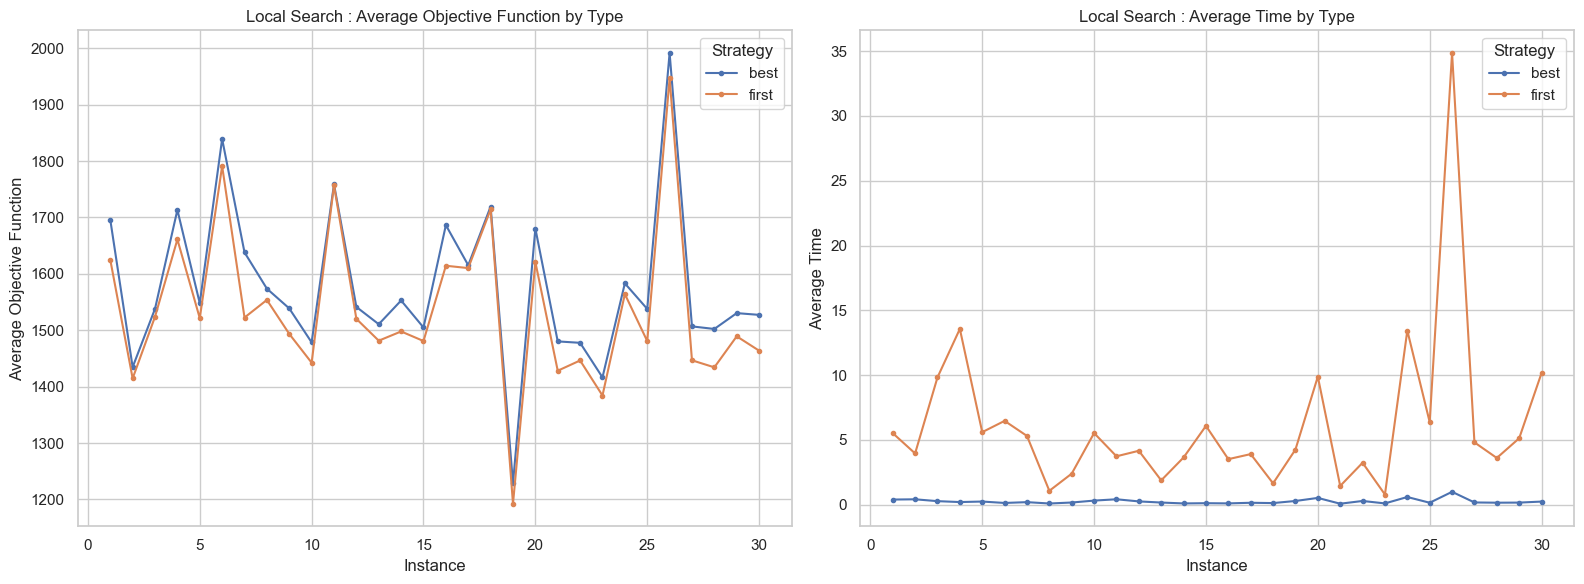

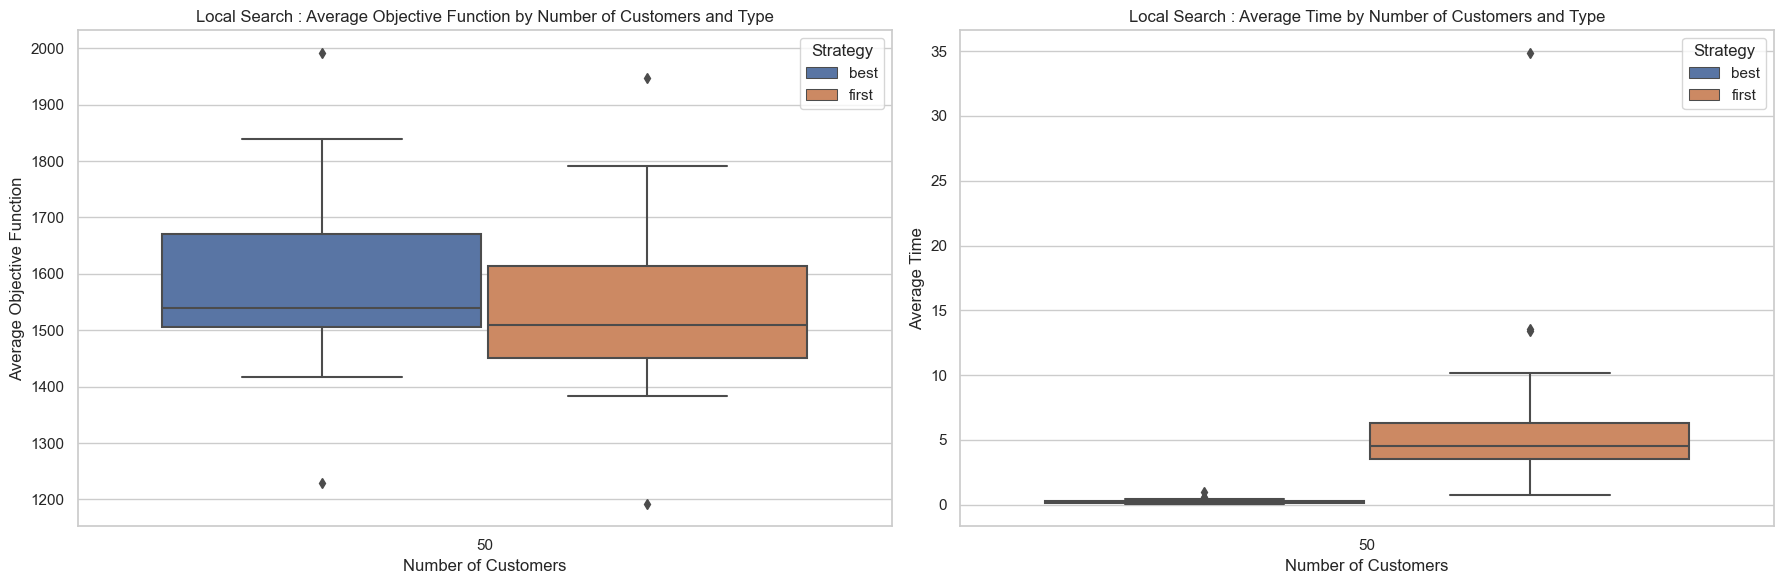

In [189]:
df_ls_str = df_ls[df_ls["neighborhood structures"] == "pickup_relocate"].copy() 
compare_obj_value_time_for_diff_algorithm_types_subplots(df_ls_str, "Local Search", 50, "strategy")
compare_obj_value_time_for_diff_algorithm_types_boxplots(df_ls_str[df_ls_str["nreq"] == 50], "Local Search", "strategy")

TODO: Perform some experimental manual tuning of relevant algorithmic parameters to find sensible parameter settings for your final experiments. Relevant parameters may be related to the degree of
randomization, neighborhood structure sizes, probabilities for the random step function in composite neighborhood structures, the cooling schedule.
Report the impact of a number of different settings on the solution quality of a selected meaningful
subset of instances.

## Simulated Annealing 

## Compare All Algorithms

In [110]:
def plot_avg_obj_func(df):

    # Unique nreq values → one plot per nreq
    unique_nreqs = sorted(df['nreq'].unique())
    n_plots = len(unique_nreqs)
    n_cols = 2
    n_rows = math.ceil(n_plots / n_cols)

    sns.set(style="whitegrid")
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), squeeze=False)

    # Colors per algorithm (automatic)
    algorithms = sorted(df['algorithm'].unique())
    palette = sns.color_palette("tab10", len(algorithms))
    algo_colors = dict(zip(algorithms, palette))

    # ---- Build plots ----
    for idx, nreq in enumerate(unique_nreqs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]
        sub = df[df['nreq'] == nreq].copy()

        ax.set_title(f"nreq = {nreq}")
        ax.set_xlabel("number")
        ax.set_ylabel("avg_obj_func")

        # Draw one curve per algorithm
        for algo in algorithms:
            df_algo = sub[sub['algorithm'] == algo]

            if df_algo.empty:
                continue

            df_algo = df_algo.sort_values("number")

            ax.plot(
                df_algo["number"],
                df_algo["avg_obj_func"],
                marker=".",
                label=algo,
                color=algo_colors[algo]
            )

        ax.legend()

    # Remove unused axes
    for idx in range(n_plots, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        fig.delaxes(axes[row][col])

    plt.tight_layout()
    plt.show()
    

In [205]:
def compare_obj_value_time_for_diff_algorithm_types_boxplots_per_nreq(
    df_all, name, legend_col, display_by_column=None, display_by_column_value=None
):
    """
    Create separate boxplots of avg_obj_func and avg_time for each 'nreq',
    with boxes grouped by `legend_col` (e.g., type or strategy).
    """
    df_plot = df_all.copy()

    # Optional filtering
    append_title = ""
    if display_by_column and display_by_column_value:
        df_plot = df_plot[df_plot[display_by_column] == display_by_column_value]
        append_title = f"{display_by_column}_{display_by_column_value}"

    # Unique number of customers
    unique_nreqs = sorted(df_plot["nreq"].unique())

    for nreq in unique_nreqs:
        sub = df_plot[df_plot["nreq"] == nreq]

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        metrics = [
            ("avg_obj_func", "Average Objective Function"),
            ("avg_time", "Average Time")
        ]

        for ax, (metric, ylabel) in zip(axes, metrics):
            sns.boxplot(
                x=legend_col,
                y=metric,
                data=sub,
                hue=legend_col,
                ax=ax,
                palette="tab10"
            )
            ax.set_xlabel(legend_col.title())
            ax.set_ylabel(ylabel)
            ax.set_title(f"{name} {append_title} (nreq={nreq}): {ylabel}")
            ax.legend(title=legend_col.title())

        plt.tight_layout()
        plt.show()

# TODO combine all dfs

In [196]:
df_all = pd.concat([df_construction, df_construction_random, df_ls], ignore_index=True)
df_all=df_all[(df_all["type"]== "with_reordering") | ((df_all["neighborhood structures"]== "remove_and_append") & (df_all["strategy"]=="best"))]

In [197]:
print(df_all['algorithm'].unique())

['c' 'rc' 'ls']


In [198]:
display(df_all)

,number,nreq,nveh,to_fulfilled,rho,avg_time,avg_obj_func,iterations,type,algorithm,neighborhood structures,strategy
60,1,50,2,48,60.86,1.550979,1698.17,46.0,with_reordering,c,NaN,NaN
61,2,50,2,45,16.88,1.762388,1446.63,45.0,with_reordering,c,NaN,NaN
62,3,50,2,46,47.73,1.381131,1538.03,44.0,with_reordering,c,NaN,NaN
63,4,50,2,47,66.33,1.587425,1713.44,45.0,with_reordering,c,NaN,NaN
64,5,50,2,45,60.86,1.250702,1576.27,44.0,with_reordering,c,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
445,26,50,2,47,27.81,0.304441,2022.97,6.0,remove_and_append_best,ls,remove_and_append,best
446,27,50,2,43,29.69,0.026052,1524.43,1.0,remove_and_append_best,ls,remove_and_append,best
447,28,50,2,41,37.19,0.035233,1502.28,1.0,remove_and_append_best,ls,remove_and_append,best
448,29,50,2,45,80.90,0.036823,1528.56,2.0,remove_and_append_best,ls,remove_and_append,best


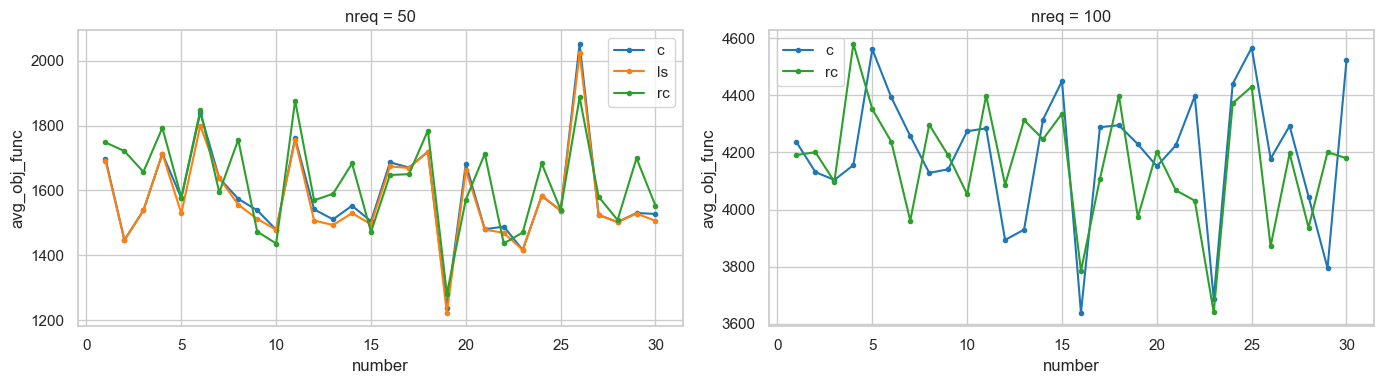

In [199]:
plot_avg_obj_func(df_all)

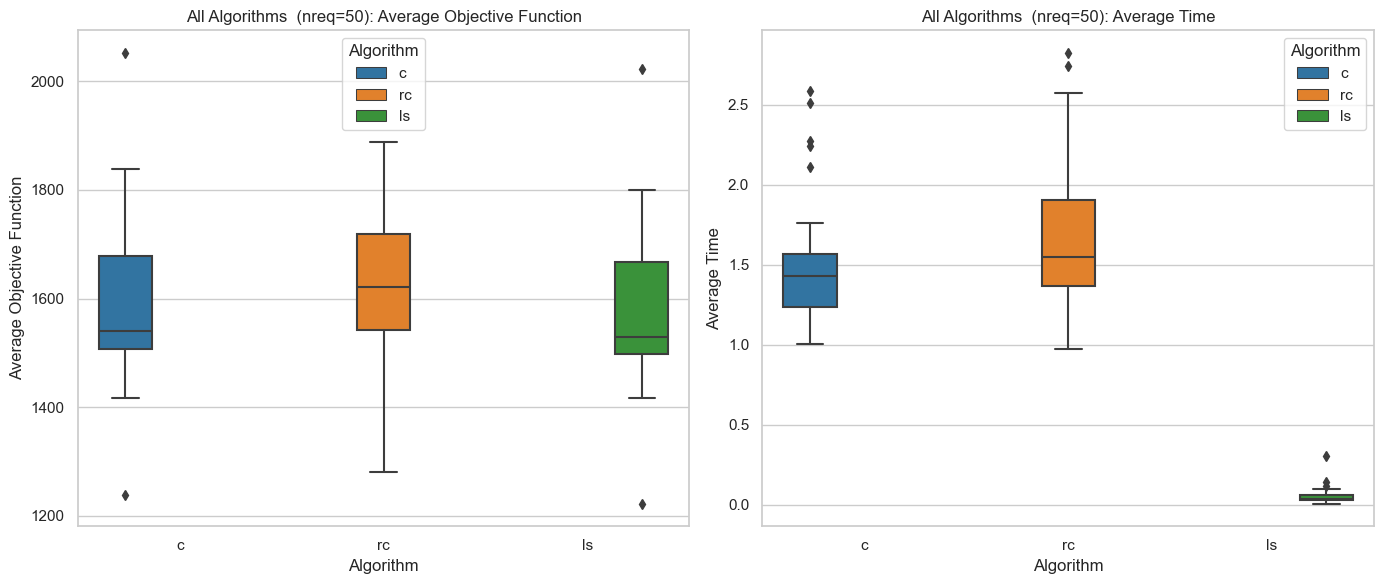

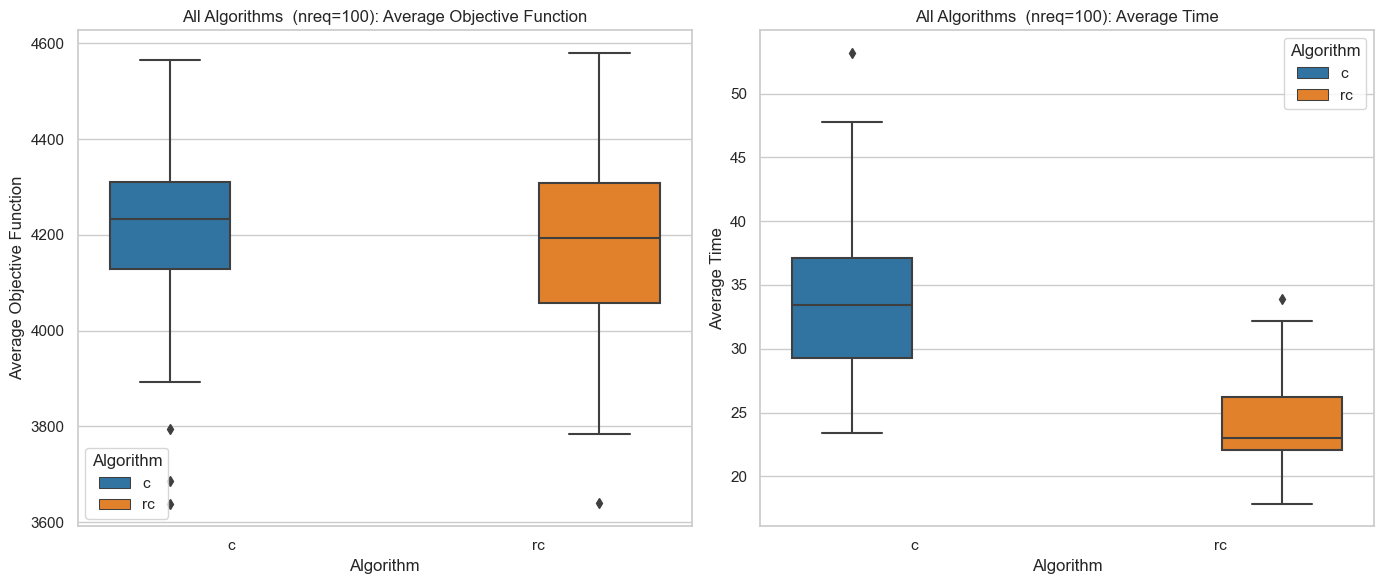

In [206]:
compare_obj_value_time_for_diff_algorithm_types_boxplots_per_nreq(df_all, "All Algorithms", "algorithm")